In [44]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import keras_hub
import tensorflow as tf
import matplotlib.cm as cm

### Load Test Image

In [80]:
img_path = keras.utils.get_file(fname="cat.jpg", origin="https://img-datasets.s3.amazonaws.com/cat.jpg")

def get_img_array(img_path, target_size):
    img = keras.utils.load_img(img_path, target_size=target_size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

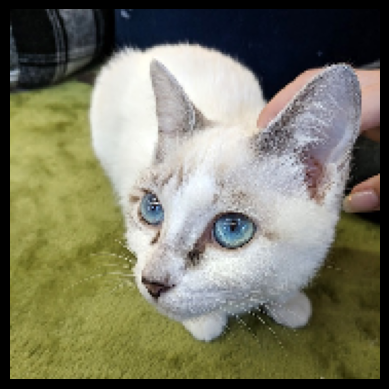

In [81]:
plt.axis("off")
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()

### Load Model

In [84]:
model = keras.models.load_model("convnet_from_scratch_with_augmentation_50-Epochs.keras")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,269 (17.96 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,138,180 (11.97 MB)

In [85]:
preds = model.predict(img_tensor)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


(1, 1)

In [86]:
preds

array([[0.7629541]], dtype=float32)

In [87]:
np.argmax(preds[0])

np.int64(0)

In [88]:
layer_outputs = []
layer_names = []

for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.MaxPooling2D)):
        layer_outputs.append(layer.output)
        layer_names.append(layer.name)

last_conv_layer_model = keras.Model(inputs=model.input, outputs=layer_outputs)
last_conv_layer_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,576 (5.98 MB)

 Trainable params: 1,568,576 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
def get_top_class_gradients(img_array):
    last_conv_layer_output = 0
    with tf.GradientTape() as tape:
        tape.watch(last_conv_layer_output)
        preds = last_conv_layer_model(last_conv_layer_output)
        top_pred_index = keras.ops.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]
    grads = tape.gradient(top_class_channel, last_conv_layer_output)
    return grads, last_conv_layer_output
grads, last_conv_layer_output = get_top_class_gradients(img_tensor[0])
grads = keras.ops.convert_to_numpy(grads)
last_conv_layer_output = keras.ops.convert_to_numpy(last_conv_layer_output)

ValueError: Passed in object 0 of type 'int', not tf.Tensor or tf.Variable or ExtensionType.

In [54]:
pooled_grads = np.mean(grads, axis=(0, 1, 2))
last_conv_layer_output = last_conv_layer_output[0].copy()
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]
heatmap = np.mean(last_conv_layer_output, axis=-1)
heatmap

array([[ 4.91493495e-08,  6.70892405e-07,  1.05653112e-06, ...,
         5.06123024e-06,  4.69440056e-06,  2.79602750e-06],
       [-3.90322782e-07,  7.60176647e-07,  7.39932943e-07, ...,
         6.14115834e-06,  7.12787551e-06,  4.34473395e-06],
       [-4.76936179e-07,  7.32259309e-07,  1.02066099e-06, ...,
         5.48060507e-06,  6.78779088e-06,  4.37264225e-06],
       ...,
       [-2.70061861e-07, -3.51978343e-07, -1.02307212e-07, ...,
         3.29606792e-07,  1.05679391e-07, -1.14496984e-07],
       [-4.51987432e-07, -5.25791336e-07, -4.15838088e-07, ...,
        -1.78682996e-07, -4.81272252e-07, -3.29849769e-07],
       [-3.88310923e-07, -5.89426008e-07, -5.94120479e-07, ...,
        -6.04494744e-07, -7.76068532e-07, -4.74114358e-07]],
      shape=(45, 45), dtype=float32)

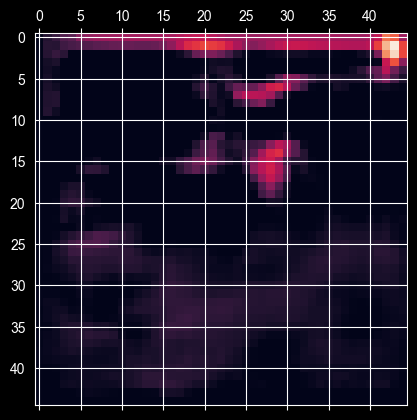

In [55]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap)

In [56]:
img = keras.utils.load_img(img_path)
img = keras.utils.img_to_array(img)
heatmap = np.uint8(255 * heatmap)
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]
jet_heatmap = keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)
superimposed_img = jet_heatmap * 0.4 + img
superimposed_img = keras.utils.array_to_img(superimposed_img)
save_path = "elephant_cam.jpg"
superimposed_img.save(save_path)

C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_31680\4057099807.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")
